In [ ]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.lines import Line2D

PROJECT_ROOT = Path("/Users/ydnkka/Desktop/PhD Project/projects/scotland")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from sse_detection.lib.sse_detection import (  # noqa: E402
    load_sequence_data,
    build_transition_network,
    build_cluster_stats,
    build_cluster_attributes,
    build_cluster_table,
    add_sse_node_metrics

)

%load_ext autoreload
%autoreload 2

out_path = PROJECT_ROOT / "sse_detection/results/sse_outputs"

out_path.mkdir(exist_ok=True)
# cluster_table = pd.read_parquet(out_path / "cluster_table")
# edge_table = pd.read_parquet(out_path / "edge_table")

In [ ]:
df = load_sequence_data()
edge_table, _, component_map = build_transition_network(df)
cluster_stats = build_cluster_stats(df, edge_table)
cluster_att = build_cluster_attributes(df)
cluster_att["connected_components"] = cluster_att["cluster_id"].map(component_map)
cluster_table = build_cluster_table(cluster_att, cluster_stats, edge_table)

In [ ]:
cluster_table = add_sse_node_metrics(cluster_table)

In [2]:
display(cluster_table.head(10))

,cluster_id,window_id,window_idx,wn_start_date,wn_mid_date,wn_end_date,wn_positive_tests,wn_no_sequences,wn_prop_sequenced,cluster_size,...,focused_amplification_n,onward_burden_score,onward_burden_n,composite_sse_score,composite_sse_score_n,composite_sse_score_null_mean,composite_sse_score_null_sd,composite_sse_score_null_z,composite_sse_score_upper_p,candidate_rank
0,W001|B.1.1.406|R0.3|C1,W001,1,2020-07-04,2020-07-14 12:00:00,2020-07-25,342.0,63,0.184211,38,...,4.0,1.0,4.0,1.0,6.0,1.0,0.0,NaN,1.0,13057.0
1,W001|B.1.1.369|R0.3|C2,W001,1,2020-07-04,2020-07-14 12:00:00,2020-07-25,342.0,63,0.184211,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,W001|B.1|R0.3|C1,W001,1,2020-07-04,2020-07-14 12:00:00,2020-07-25,342.0,63,0.184211,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,W001|B.1.36|R0.3|C1,W001,1,2020-07-04,2020-07-14 12:00:00,2020-07-25,342.0,63,0.184211,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,W001|B.1|R0.3|C2,W001,1,2020-07-04,2020-07-14 12:00:00,2020-07-25,342.0,63,0.184211,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,W001|B.1.1.10|R0.3|S0,W001,1,2020-07-04,2020-07-14 12:00:00,2020-07-25,342.0,63,0.184211,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,W001|B.1.1.170|R0.3|S0,W001,1,2020-07-04,2020-07-14 12:00:00,2020-07-25,342.0,63,0.184211,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,W001|B.1.1.369|R0.3|S1,W001,1,2020-07-04,2020-07-14 12:00:00,2020-07-25,342.0,63,0.184211,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,W001|B.1.1.369|R0.3|S3,W001,1,2020-07-04,2020-07-14 12:00:00,2020-07-25,342.0,63,0.184211,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,W001|B.1.1.406|R0.3|S2,W001,1,2020-07-04,2020-07-14 12:00:00,2020-07-25,342.0,63,0.184211,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
display(edge_table.head(10))

,source,target,source_window_id,target_window_id,source_window_idx,target_window_idx,n_shared_sequences
0,W001|B.1.1.406|R0.3|C1,W003|B.1.1.406|R0.3|C1,W001,W002,1,2,25
1,W001|B.1|R0.3|C1,W003|B.1|R0.3|C1,W001,W002,1,2,3
2,W001|B.1.1.369|R0.3|C2,W003|B.1.1.369|R0.3|C1,W001,W002,1,2,2
3,W001|B.1.1.170|R0.3|S0,W003|B.1.1.170|R0.3|S0,W001,W002,1,2,1
4,W001|B.1.1.406|R0.3|C1,W003|B.1.1.406|R0.3|C3,W001,W002,1,2,1
5,W001|B.1.1.406|R0.3|C1,W003|B.1.1.406|R0.3|S2,W001,W002,1,2,1
6,W001|B.1.1.406|R0.3|S2,W003|B.1.1.406|R0.3|C3,W001,W002,1,2,1
7,W001|B.1.1.406|R0.3|S3,W003|B.1.1.406|R0.3|S4,W001,W002,1,2,1
8,W001|B.1|R0.3|C2,W003|B.1|R0.3|C2,W001,W002,1,2,1
9,W003|AD.2|R0.3|C1,W005|AD.2|R0.3|C1,W002,W003,2,3,116


In [4]:
print(cluster_table["candidate_tier"].value_counts())

candidate_tier
size_ineligible                  85947
background_or_low_information    11827
possible_review                    633
high_priority_review               597
high_score_uncalibrated              2
Name: count, dtype: int64


In [2]:
from utils import new_figure, add_panel_labels, WIDTHS, CONTEXTS

from sse_detection.lib.palettes import CANDIDATE_COLOR, BACKGROUND_COLOR, GRAY

DEFAULT_CANDIDATE_TIERS = ("high_priority_review",)
INELIGIBLE = "size_ineligible"


# --------------------------------------------------------------------------- #
# Shared helpers
# --------------------------------------------------------------------------- #
def _candidate_mask(
    df: pd.DataFrame,
    *,
    tier_col: str = "candidate_tier",
    candidate_tiers: tuple[str, ...] = DEFAULT_CANDIDATE_TIERS,
) -> pd.Series:
    """Boolean candidate flag from the tier column."""
    if tier_col not in df.columns:
        raise KeyError(f"{tier_col!r} not found in node table.")
    return df[tier_col].isin(candidate_tiers)


def _legend_candidate_background(ax, *, loc: str = "best") -> None:
    """Filled = candidate, open = background, in project colours."""
    handles = [
        Line2D(
            [],
            [],
            marker="o",
            linestyle="none",
            markersize=5,
            markerfacecolor=CANDIDATE_COLOR,
            markeredgecolor=CANDIDATE_COLOR,
            label="Candidate",
        ),
        Line2D(
            [],
            [],
            marker="o",
            linestyle="none",
            markersize=5,
            markerfacecolor="none",
            markeredgecolor=BACKGROUND_COLOR,
            label="Background",
        ),
    ]
    ax.legend(handles=handles, loc=loc, frameon=False)


# --------------------------------------------------------------------------- #
# 1. Null calibration  (the first plot to look at)
# --------------------------------------------------------------------------- #
def plot_null_calibration(
    node_stats: pd.DataFrame,
    *,
    p_col: str = "composite_sse_score_upper_p",
    obs_col: str = "composite_sse_score",
    null_mean_col: str = "composite_sse_score_null_mean",
    tier_col: str = "candidate_tier",
    candidate_tiers: tuple[str, ...] = DEFAULT_CANDIDATE_TIERS,
    width: "WIDTHS" = "double",
    width_in: float | None = None,
    height_in: float = 3.2,
    context: "CONTEXTS" = "paper",
    font_scale: float = 1.0,
    n_bins: int = 30,
    size_ineligible: str = INELIGIBLE,
) -> Figure:
    """Is the permutation null calibrated?

    Panel A: histogram of upper-tail p-values. Background nodes should be ~uniform
    on (0, 1); a spike near 0 is genuine signal. A non-uniform bulk or a spike
    near 1 indicates a miscalibrated null.
    Panel B: observed composite vs. its null mean, coloured by candidate status.
    Candidates should sit above the identity line.
    """
    df = node_stats[node_stats[tier_col]!=size_ineligible].copy()
    fig, axes = new_figure(
        ncols=2,
        width=width,
        width_in=width_in,
        height_in=height_in,
        context=context,
        font_scale=font_scale,
        layout="constrained",
    )
    ax_p, ax_scatter = axes[0], axes[1]
    is_cand = _candidate_mask(df, tier_col=tier_col, candidate_tiers=candidate_tiers)

    # Panel A — p-value histogram with a uniform reference line.
    p = df[p_col].dropna().to_numpy()
    ax_p.hist(
        p,
        bins=n_bins,
        range=(0, 1),
        color=BACKGROUND_COLOR,
        edgecolor="white",
        linewidth=0.4,
    )
    ax_p.axhline(
        len(p) / n_bins,
        color="black",
        linestyle="--",
        linewidth=0.8,
        label="Uniform expectation",
    )
    ax_p.set_xlabel("Composite null upper-tail $p$")
    ax_p.set_ylabel("Number of nodes")
    ax_p.legend(loc="best", frameon=False)

    # Panel B — observed vs null mean.
    for mask, color, face, label in [
        (~is_cand, BACKGROUND_COLOR, "none", "Background"),
        (is_cand, CANDIDATE_COLOR, CANDIDATE_COLOR, "Candidate"),
    ]:
        sub = df.loc[mask, [null_mean_col, obs_col]].dropna()
        ax_scatter.scatter(
            sub[null_mean_col],
            sub[obs_col],
            s=6,
            facecolors=face,
            edgecolors=color,
            linewidths=0.4,
            alpha=0.5,
            label=label,
        )
    lo = float(np.nanmin([df[null_mean_col].min(), df[obs_col].min()]))
    hi = float(np.nanmax([df[null_mean_col].max(), df[obs_col].max()]))
    ax_scatter.plot([lo, hi], [lo, hi], color="black", linewidth=0.8, linestyle="--")
    ax_scatter.set_xlabel("Null mean composite score")
    ax_scatter.set_ylabel("Observed composite score")
    _legend_candidate_background(ax_scatter, loc="lower right")

    add_panel_labels([ax_p, ax_scatter])
    plt.close(fig)
    return fig

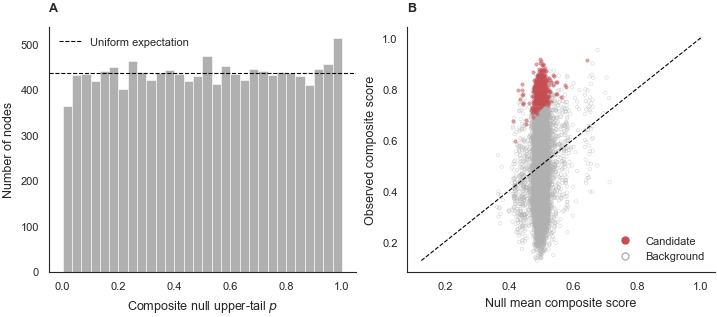

In [3]:
fig = plot_null_calibration(cluster_table)
display(fig)

In [7]:
# --------------------------------------------------------------------------- #
# 2. Volcano  (what got flagged, and how strongly)
# --------------------------------------------------------------------------- #
def plot_sse_volcano(
    node_stats: pd.DataFrame,
    *,
    z_col: str = "composite_sse_score_null_z",
    p_col: str = "composite_sse_score_upper_p",
    size_col: str = "cluster_size",
    tier_col: str = "candidate_tier",
    candidate_tiers: tuple[str, ...] = DEFAULT_CANDIDATE_TIERS,
    alpha_line: float = 0.05,
    width: "WIDTHS" = "single",
    width_in: float | None = None,
    height_in: float = 3.4,
    context: "CONTEXTS" = "paper",
    font_scale: float = 1.0,
    size_ineligible: str = INELIGIBLE
) -> Figure:
    """Volcano: null-z (x) vs. -log10(upper-p) (y), sized by cluster size.

    Filled markers are candidates; open markers background. A dashed line marks
    the significance threshold. Reveals at a glance whether flagging is driven
    by effect size or only by large clusters.
    """
    df = node_stats[node_stats[tier_col]!=size_ineligible].copy()

    fig, ax = new_figure(
        width=width, width_in=width_in, height_in=height_in,
        context=context, font_scale=font_scale, layout="constrained",
    )
    
    is_cand = _candidate_mask(
        node_stats, tier_col=tier_col, candidate_tiers=candidate_tiers
    )

    df = df[[z_col, p_col, size_col]].copy()
    df["_y"] = -np.log10(df[p_col].clip(lower=np.finfo(float).tiny))
    # marker size scaled by sqrt(cluster_size) for visual area proportionality
    s = 4 + 30 * np.sqrt(df[size_col].clip(lower=1) / df[size_col].max())

    for mask, color, face, label in [
        (~is_cand, BACKGROUND_COLOR, "none", "Background"),
        (is_cand, CANDIDATE_COLOR, CANDIDATE_COLOR, "Candidate"),
    ]:
        ax.scatter(
            df.loc[mask, z_col], df.loc[mask, "_y"], s=s[mask],
            facecolors=face, edgecolors=color, linewidths=0.4, alpha=0.55,
            label=label,
        )
    ax.axhline(
        -np.log10(alpha_line), color="black", linestyle="--", linewidth=0.8,
        label=f"$p$ = {alpha_line:g}",
    )
    ax.set_xlabel("Composite null $z$-score")
    ax.set_ylabel(r"$-\log_{10}$ upper-tail $p$")
    _legend_candidate_background(ax, loc="upper left")
    plt.close(fig)
    return fig

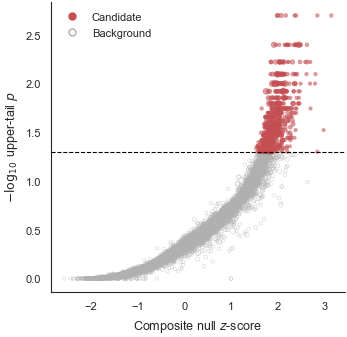

In [8]:
fig = plot_sse_volcano(cluster_table)
display(fig)

In [ ]:
# --------------------------------------------------------------------------- #
# 3. Size-confounding check  (is the signal just cluster size?)
# --------------------------------------------------------------------------- #
def plot_size_confounding(
    node_stats: pd.DataFrame,
    *,
    z_col: str = "composite_sse_score_null_z",
    log_size_col: str = "log_cluster_size",
    size_col: str = "cluster_size",
    tier_col: str = "candidate_tier",
    candidate_tiers: tuple[str, ...] = DEFAULT_CANDIDATE_TIERS,
    width: "WIDTHS" = "single",
    width_in: float | None = None,
    height_in: float = 3.4,
    context: "CONTEXTS" = "paper",
    font_scale: float = 1.0,
    size_ineligible: str = INELIGIBLE
) -> tuple[Figure, float]:
    """Null-z vs. log cluster size. Returns the figure and the Spearman rho.

    A tight upward band of candidates means the score mostly re-expresses size;
    scatter means the multi-channel evidence adds information beyond size. The
    Spearman correlation between ``z_col`` and size is returned for reporting.
    """
    df = node_stats[node_stats[tier_col]!=size_ineligible].copy()
    fig, ax = new_figure(
        width=width, width_in=width_in, height_in=height_in,
        context=context, font_scale=font_scale, layout="constrained",
    )

    is_cand = _candidate_mask(
        df, tier_col=tier_col, candidate_tiers=candidate_tiers
    )

    if log_size_col in df.columns:
        x = df[log_size_col]
        xlabel = "log(1 + cluster size)"
    else:
        x = np.log1p(df[size_col])
        xlabel = "log(1 + cluster size)"

    for mask, color, face, label in [
        (~is_cand, BACKGROUND_COLOR, "none", "Background"),
        (is_cand, CANDIDATE_COLOR, CANDIDATE_COLOR, "Candidate"),
    ]:
        ax.scatter(
            x[mask], df.loc[mask, z_col], s=6,
            facecolors=face, edgecolors=color, linewidths=0.4, alpha=0.5,
            label=label,
        )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Composite null $z$-score")

    valid =  pd.notna(x) & df[z_col].notna()
    rho = float(
        pd.Series(x[valid]).corr(df.loc[valid, z_col], method="spearman")
    )
    ax.set_title(rf"Spearman $\rho$ = {rho:.2f}", fontsize=plt.rcParams["font.size"])
    _legend_candidate_background(ax, loc="lower right")
    plt.close(fig)
    return fig, rho

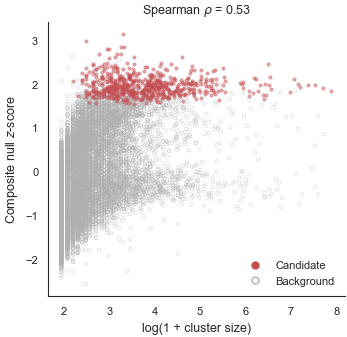

In [10]:
fig, nn = plot_size_confounding(cluster_table)
display(fig)

In [6]:
# --------------------------------------------------------------------------- #
# 4. Component contributions  (which channels drive flagging)
# --------------------------------------------------------------------------- #
def plot_component_contributions(
    node_stats: pd.DataFrame,
    *,
    component_cols: list[str] | None = None,
    component_labels: dict[str, str] | None = None,
    tier_col: str = "candidate_tier",
    candidate_tiers: tuple[str, ...] = DEFAULT_CANDIDATE_TIERS,
    width: "WIDTHS" = "double",
    width_in: float | None = None,
    height_in: float = 4.5,
    context: "CONTEXTS" = "paper",
    font_scale: float = 1.0,
    size_ineligible: str = INELIGIBLE
) -> Figure:
    """Small-multiples: per-window percentile-rank component distributions,
    candidate vs background.

    Shows which evidence channels separate candidates from background. Each
    panel is one component; overlaid KDEs (filled = candidate) make the
    separation visible per channel.
    """
    df = node_stats[node_stats[tier_col]!=size_ineligible].copy()
        # "sampling_adjusted_excess_size",
        # "log_cluster_size",
        # "log_excess_over_upstream",
        # "effective_successors",
        # # "onward_expansion_proxy",
        # "log_downstream_burden",
        # "coherence_score",
    if component_cols is None:
        component_cols = [
            "log_cluster_size_pct_window",
            "sampling_adjusted_excess_size_pct_window",
            "log_excess_over_upstream_pct_window",
            "effective_successors_pct_window",
            "log_downstream_burden_pct_window",
            "coherence_score_pct_window",
        ]
    component_cols = [c for c in component_cols if c in df.columns]
    if component_labels is None:
        component_labels = {
            "log_cluster_size_pct_window": "Raw size", 
            "sampling_adjusted_excess_size_pct_window": "Excess size",
            "log_excess_over_upstream_pct_window": "Excess over upstream",
            "effective_successors_pct_window": "Effective successors",
            "log_downstream_burden_pct_window": "Downstream burden",
            "coherence_score_pct_window": "Coherence (homogeneity)",
        }

    n = len(component_cols)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = new_figure(
        nrows=nrows, ncols=ncols, width=width, width_in=width_in,
        height_in=height_in, context=context, font_scale=font_scale,
        layout="constrained", sharex=True,
    )
    axes = axes.ravel()
    is_cand = _candidate_mask(
        df, tier_col=tier_col, candidate_tiers=candidate_tiers
    )

    for ax, col in zip(axes, component_cols):
        for mask, color, fill, label in [
            (~is_cand, BACKGROUND_COLOR, False, "Background"),
            (is_cand, CANDIDATE_COLOR, True, "Candidate"),
        ]:
            
            vals = df[mask][col].to_numpy()
            if vals.size < 5:
                continue
            ax.hist(
                vals, bins=25, range=(0, 1), density=True,
                histtype="stepfilled" if fill else "step",
                color=color, alpha=0.35 if fill else 1.0,
                edgecolor=color, linewidth=1.0, label=label,
            )
        ax.set_title(component_labels.get(col, col), fontsize=plt.rcParams["font.size"])
        ax.set_xlim(0, 1)
        ax.set_yticks([])
    for ax in axes[n:]:
        ax.set_visible(False)
    for ax in axes[: n][-ncols:]:
        ax.set_xlabel("Per-window percentile rank")

    handles = [
        Line2D([], [], color=CANDIDATE_COLOR, linewidth=4, alpha=0.5, label="Candidate"),
        Line2D([], [], color=BACKGROUND_COLOR, linewidth=1.5, label="Background"),
    ]
    fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
    add_panel_labels(axes[:n])
    plt.close(fig)
    return fig

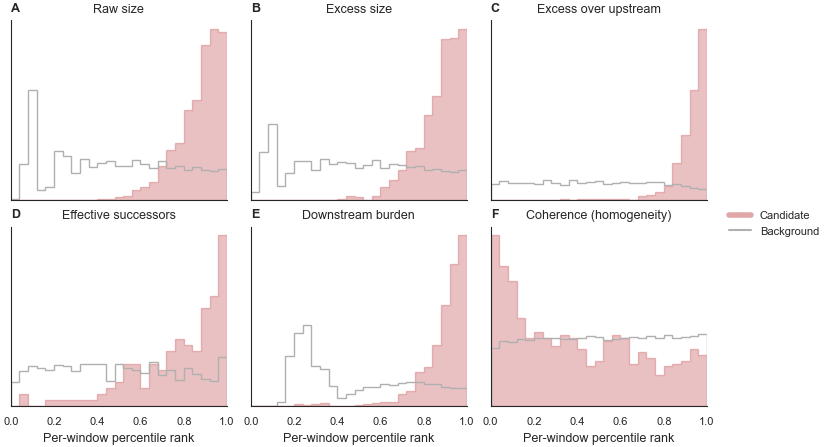

In [7]:
fig = plot_component_contributions(cluster_table)
display(fig)

In [5]:
# --------------------------------------------------------------------------- #
# 5. SSE phenotype  (amplifier vs disseminator)
# --------------------------------------------------------------------------- #
def plot_sse_phenotype(
    node_stats: pd.DataFrame,
    *,
    focused_col: str = "focused_amplification_score",
    onward_col: str = "onward_burden_score",
    size_col: str = "cluster_size",
    tier_col: str = "candidate_tier",
    candidate_tiers: tuple[str, ...] = DEFAULT_CANDIDATE_TIERS,
    width: "WIDTHS" = "single",
    width_in: float | None = None,
    height_in: float = 3.6,
    context: "CONTEXTS" = "paper",
    font_scale: float = 1.0,
    size_ineligible: str = INELIGIBLE
) -> Figure:
    """Focused amplification (x) vs. onward burden (y), candidates highlighted.

    Separates two SSE phenotypes: focused amplifiers (high focused, lower onward)
    vs. disseminators (high onward burden). Quadrant guides at the medians.
    """
    df = node_stats[node_stats[tier_col]!=size_ineligible].copy()
    fig, ax = new_figure(
        width=width, width_in=width_in, height_in=height_in,
        context=context, font_scale=font_scale, layout="constrained",
    )
    is_cand = _candidate_mask(
        df, tier_col=tier_col, candidate_tiers=candidate_tiers
    )
    s = 4 + 30 * np.sqrt(
        df[size_col].clip(lower=1) / df[size_col].max()
    )
    for mask, color, face, label in [
        (~is_cand, BACKGROUND_COLOR, "none", "Background"),
        (is_cand, CANDIDATE_COLOR, CANDIDATE_COLOR, "Candidate"),
    ]:
        ax.scatter(
            df.loc[mask, focused_col], df.loc[mask, onward_col],
            s=s[mask], facecolors=face, edgecolors=color, linewidths=0.4,
            alpha=0.55, label=label,
        )
    ax.axvline(df[focused_col].median(), color=GRAY, linewidth=0.6, linestyle=":")
    ax.axhline(df[onward_col].median(), color=GRAY, linewidth=0.6, linestyle=":")
    ax.set_xlabel("Focused amplification score")
    ax.set_ylabel("Onward burden score")
    _legend_candidate_background(ax, loc="upper left")
    plt.close(fig)
    return fig

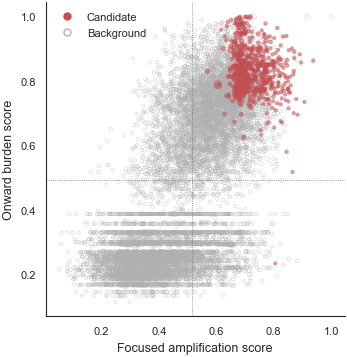

In [6]:
fig = plot_sse_phenotype(cluster_table)
display(fig)

In [15]:
# --------------------------------------------------------------------------- #
# 6. Temporal context  (candidates over epidemic time)
# --------------------------------------------------------------------------- #
def plot_temporal_candidates(
    node_stats: pd.DataFrame,
    *,
    window_col: str = "window_idx",
    tier_col: str = "candidate_tier",
    candidate_tiers: tuple[str, ...] = DEFAULT_CANDIDATE_TIERS,
    epidemic_col: str | None = "wn_positive_tests",
    width: "WIDTHS" = "double",
    width_in: float | None = None,
    height_in: float = 3.2,
    context: "CONTEXTS" = "paper",
    font_scale: float = 1.0,
    size_ineligible: str = INELIGIBLE
) -> tuple[Figure, pd.DataFrame]:
    """Candidate count per window over time, optionally overlaid on an epidemic
    series. Returns the figure and the per-window summary table.

    Tells you whether detected superspreading tracks epidemic waves or merely
    sequencing intensity.
    """
    df = node_stats[node_stats[tier_col]!=size_ineligible].copy()
    fig, ax = new_figure(
        width=width, width_in=width_in, height_in=height_in,
        context=context, font_scale=font_scale, layout="constrained",
    )
    is_cand = _candidate_mask(
        df, tier_col=tier_col, candidate_tiers=candidate_tiers
    )

    summary = (
        df.assign(_cand=is_cand)
        .groupby(window_col, dropna=False)
        .agg(n_nodes=("_cand", "size"), n_candidates=("_cand", "sum"))
        .reset_index()
        .sort_values(window_col)
    )
    summary["candidate_rate"] = summary["n_candidates"] / summary["n_nodes"]

    ax.bar(
        summary[window_col], summary["n_candidates"],
        color=CANDIDATE_COLOR, alpha=0.85, width=0.9, label="Candidate nodes",
    )
    ax.set_xlabel("Window index")
    ax.set_ylabel("Candidate nodes", color=CANDIDATE_COLOR)
    ax.tick_params(axis="y", labelcolor=CANDIDATE_COLOR)

    if epidemic_col is not None and epidemic_col in df.columns:
        epi = (
            df.groupby(window_col, dropna=False)[epidemic_col]
            .first().reset_index().sort_values(window_col)
        )
        ax2 = ax.twinx()
        ax2.plot(
            epi[window_col], epi[epidemic_col],
            color="black", linewidth=1.2, label=epidemic_col,
        )
        ax2.set_ylabel("Window positive tests", color="black")
        ax2.set_ylim(bottom=0)

    plt.close(fig)
    return fig, summary

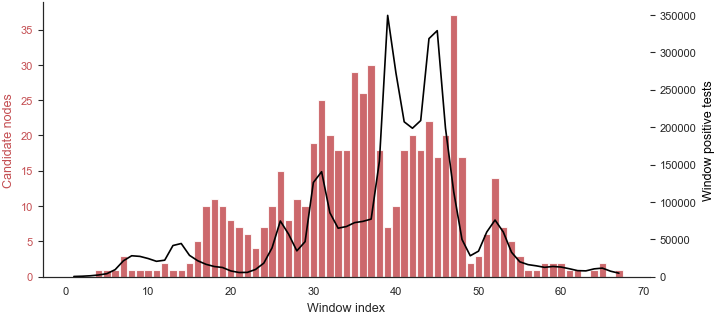

In [16]:
fig, df1 = plot_temporal_candidates(cluster_table)
display(fig)

In [17]:
# --------------------------------------------------------------------------- #
# 7. Candidate rate by clade / VOC
# --------------------------------------------------------------------------- #
def plot_candidate_rate_by_group(
    node_stats: pd.DataFrame,
    *,
    group_col: str = "clade",
    tier_col: str = "candidate_tier",
    candidate_tiers: tuple[str, ...] = DEFAULT_CANDIDATE_TIERS,
    min_group_n: int = 20,
    width: "WIDTHS" = "single",
    width_in: float | None = None,
    height_in: float = 3.6,
    context: "CONTEXTS" = "paper",
    font_scale: float = 1.0,
    size_ineligible: str = INELIGIBLE,
) -> tuple[Figure, pd.DataFrame]:
    """Candidate proportion by ``group_col`` (clade / WHO VOC) with Wilson 95% CIs.

    Returns the figure and the per-group rate table. Groups with fewer than
    ``min_group_n`` nodes are dropped. Filled point = group whose CI excludes the
    overall rate (i.e. significantly enriched/depleted).
    """
    df = node_stats[node_stats[tier_col] != size_ineligible].copy()
    is_cand = _candidate_mask(df, tier_col=tier_col, candidate_tiers=candidate_tiers)
    tab = (
        df.assign(_cand=is_cand.astype(int))
        .groupby(group_col, dropna=False)
        .agg(n=("_cand", "size"), k=("_cand", "sum"))
        .reset_index()
    )
    tab = tab[tab["n"] >= min_group_n].copy()
    tab["rate"] = tab["k"] / tab["n"]

    # Wilson score interval.
    z = 1.96
    n, p = tab["n"].to_numpy(), tab["rate"].to_numpy()
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = (z / denom) * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    tab["lo"], tab["hi"] = centre - half, centre + half
    tab = tab.sort_values("rate", ascending=True).reset_index(drop=True)

    overall = float(is_cand.mean())
    excludes_overall = (tab["lo"] > overall) | (tab["hi"] < overall)

    fig, ax = new_figure(
        width=width,
        width_in=width_in,
        height_in=height_in,
        context=context,
        font_scale=font_scale,
        layout="constrained",
    )

    y = np.arange(len(tab))
    for yi, (_, r), filled in zip(y, tab.iterrows(), excludes_overall):
        ax.plot([r["lo"], r["hi"]], [yi, yi], color="black", linewidth=0.9, zorder=1)
        ax.scatter(
            r["rate"],
            yi,
            s=28,
            zorder=2,
            facecolors=CANDIDATE_COLOR if filled else "none",
            edgecolors=CANDIDATE_COLOR,
            linewidths=1.0,
        )
    ax.axvline(overall, color=GRAY, linestyle="--", linewidth=0.8, label="Overall rate")
    ax.set_yticks(y)
    ax.set_yticklabels(tab[group_col].astype(str))
    ax.set_xlabel("Candidate proportion (Wilson 95% CI)")
    ax.set_ylabel(group_col.replace("_", " ").title())
    ax.legend(loc="lower right", frameon=False)
    plt.close(fig)
    return fig, tab

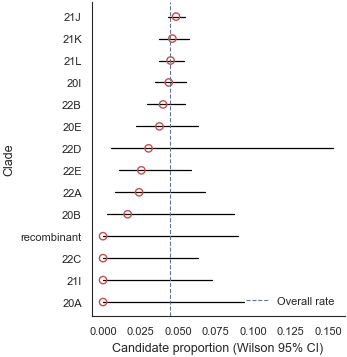

In [18]:
fig, df2 = plot_candidate_rate_by_group(cluster_table)
display(fig)

In [19]:
# --------------------------------------------------------------------------- #
# 8. Candidate tier by graph role
# --------------------------------------------------------------------------- #
def plot_tier_by_graph_role(
    node_stats: pd.DataFrame,
    *,
    role_col: str = "primary_graph_role",
    tier_col: str = "candidate_tier",
    candidate_tiers: tuple[str, ...] = DEFAULT_CANDIDATE_TIERS,
    exclude_censored: bool = True,
    width: "WIDTHS" = "onehalf",
    width_in: float | None = None,
    height_in: float = 3.4,
    context: "CONTEXTS" = "paper",
    font_scale: float = 1.0,
    size_ineligible: str = INELIGIBLE,
) -> tuple[Figure, pd.DataFrame]:
    """
    Plot candidate proportion by mutually exclusive primary graph role.

    This function assumes that ``node_stats`` already contains a
    ``primary_graph_role`` column created during SSE metric construction.

    The plot answers:

        Among size-eligible, non-censored nodes in each graph role,
        what proportion are SSE candidates?
    """
    required_cols = [tier_col, role_col]
    missing = [col for col in required_cols if col not in node_stats.columns]

    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = node_stats.loc[node_stats[tier_col] != size_ineligible].copy()

    if df.empty:
        raise ValueError("No size-eligible nodes available for plotting.")

    if exclude_censored:
        keep = pd.Series(True, index=df.index)

        for col in ("left_censored", "right_censored", "boundary_censored"):
            if col in df.columns:
                keep &= ~df[col].fillna(False).astype(bool)

        df = df.loc[keep].copy()

    if df.empty:
        raise ValueError("No nodes remain after applying censoring exclusions.")

    df[role_col] = df[role_col].fillna("unknown").astype("string")

    is_candidate = _candidate_mask(
        df,
        tier_col=tier_col,
        candidate_tiers=candidate_tiers,
    )

    df["_is_candidate"] = is_candidate.astype(bool)

    role_labels = {
        "isolated": "Isolated",
        "single_outgoing_source": "Single-outgoing source",
        "source_branching": "Source branching",
        "single_incoming_sink": "Single-incoming sink",
        "merging_sink": "Merging sink",
        "linear_continuation": "Linear continuation",
        "internal_branching": "Internal branching",
        "internal_merging": "Internal merging",
        "merge_and_branch": "Merge + branch",
        "other": "Other",
        "unknown": "Unknown",
    }

    role_order = [
        "isolated",
        "single_outgoing_source",
        "source_branching",
        "linear_continuation",
        "internal_branching",
        "internal_merging",
        "merge_and_branch",
        "merging_sink",
        "single_incoming_sink",
        "other",
        "unknown",
    ]

    tab = (
        df.groupby(role_col, dropna=False)
        .agg(
            n=("_is_candidate", "size"),
            k=("_is_candidate", "sum"),
        )
        .reset_index()
        .rename(columns={role_col: "primary_graph_role"})
    )

    tab["rate"] = tab["k"] / tab["n"]

    tab["role_label"] = (
        tab["primary_graph_role"]
        .astype(str)
        .map(role_labels)
        .fillna(tab["primary_graph_role"].astype(str))
    )

    tab["_role_order"] = pd.Categorical(
        tab["primary_graph_role"].astype(str),
        categories=role_order,
        ordered=True,
    )

    tab = (
        tab.sort_values(["_role_order", "primary_graph_role"])
        .drop(columns="_role_order")
        .reset_index(drop=True)
    )

    fig, ax = new_figure(
        width=width,
        width_in=width_in,
        height_in=height_in,
        context=context,
        font_scale=font_scale,
        layout="constrained",
    )

    x = np.arange(len(tab))

    ax.bar(
        x,
        tab["rate"],
        color=CANDIDATE_COLOR,
        alpha=0.85,
        width=0.7,
    )

    overall = float(df["_is_candidate"].mean())

    ax.axhline(
        overall,
        color=GRAY,
        linestyle="--",
        linewidth=0.8,
        label="Overall tested-node rate",
    )

    for xi, row in zip(x, tab.itertuples(index=False)):
        ax.text(
            xi,
            row.rate,
            f"{row.k:,}/{row.n:,}",
            ha="center",
            va="bottom",
            fontsize=plt.rcParams["font.size"] * 0.75,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        tab["role_label"],
        rotation=30,
        ha="right",
    )

    ax.set_ylabel("Candidate proportion")
    ax.set_ylim(0, max(0.05, min(1.0, tab["rate"].max() * 1.18)))
    ax.legend(loc="upper left", frameon=False)

    plt.close(fig)

    return fig, tab

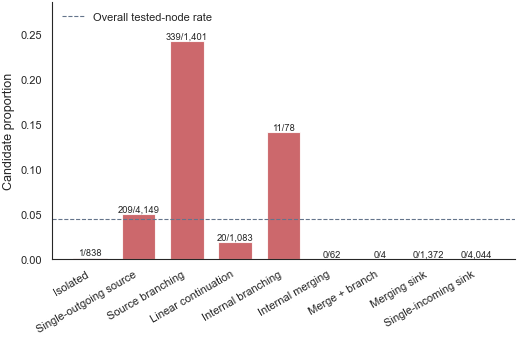

In [20]:
fig, df3 = plot_tier_by_graph_role(cluster_table)
display(fig)